In [4]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
import joblib

# Load CSVs
panel_path = r"C:\Users\dedee\Downloads\epidemic-project\data_curated\panel_state_daily.csv"
adj_path = r"C:\Users\dedee\Downloads\epidemic-project\data_curated\state_adjacency.csv"

panel = pd.read_csv(panel_path, parse_dates=['Date'])
adj = pd.read_csv(adj_path, index_col=0)  # adjacency matrix with states as index/cols

# create Z: elevated risk if active > 75th percentile or growth > 10%
panel = panel.sort_values(['state','Date'])
panel['active_lag1'] = panel.groupby('state')['active'].shift(1).fillna(0)
panel['active_growth'] = (panel['active'] - panel['active_lag1']).fillna(0)
thresholds = panel.groupby('state')['active'].quantile(0.75).to_dict()
panel['Z'] = panel.apply(lambda row: 1 if (row['active']>thresholds[row['state']] 
                                           or row['active_growth']>0.10*max(1,row['active_lag1'])) else 0, axis=1)

# lag features
panel['Z_t'] = panel.groupby('state')['Z'].shift(-0)
panel['Z_lag1'] = panel.groupby('state')['Z'].shift(1).fillna(0)

# mean neighbor Z at t-1
def compute_mean_neighbor(row):
    st=row['state']; date=row['Date']-pd.Timedelta(days=1)
    if st not in adj.index: return 0
    nbs = adj.loc[st][adj.loc[st]==1].index.tolist()
    if not nbs: return 0
    prior = panel[(panel['state'].isin(nbs)) & (panel['Date']==date)]
    return prior['Z'].mean() if not prior.empty else 0

panel['mean_nb_lag1'] = panel.apply(compute_mean_neighbor, axis=1)
panel['trend_pred'] = panel['active_growth'] / (panel['active_lag1'] + 1e-6)

# feature matrix and target
feat_cols = ['Z_lag1','mean_nb_lag1','trend_pred','daily_tests','daily_vax']
for c in feat_cols:
    if c not in panel.columns:
        panel[c]=0

train = panel.dropna(subset=['Z_t']).copy()
X = train[feat_cols].fillna(0).values
y = train['Z_t'].astype(int).values

scaler = StandardScaler()
Xs = scaler.fit_transform(X)

clf = LogisticRegression(max_iter=200)
clf.fit(Xs, y)
print("Logistic coefficients:", clf.coef_, clf.intercept_)

# save model and scaler
joblib.dump(clf, r"C:\Users\dedee\Downloads\epidemic-project\models\markov_logistic.pkl")
joblib.dump(scaler, r"C:\Users\dedee\Downloads\epidemic-project\models\markov_scaler.pkl")


Logistic coefficients: [[1.81090856 0.67051555 3.37094369 0.         0.        ]] [-1.60216109]


['C:\\Users\\dedee\\Downloads\\epidemic-project\\models\\markov_scaler.pkl']

summary statistics

In [5]:
print("Number of training samples:", X.shape[0])
print("Number of features:", X.shape[1])
print("Target Z distribution:")
print(pd.Series(y).value_counts())


Number of training samples: 25761
Number of features: 5
Target Z distribution:
0    18858
1     6903
Name: count, dtype: int64


Scatter plot of actual vs predicted

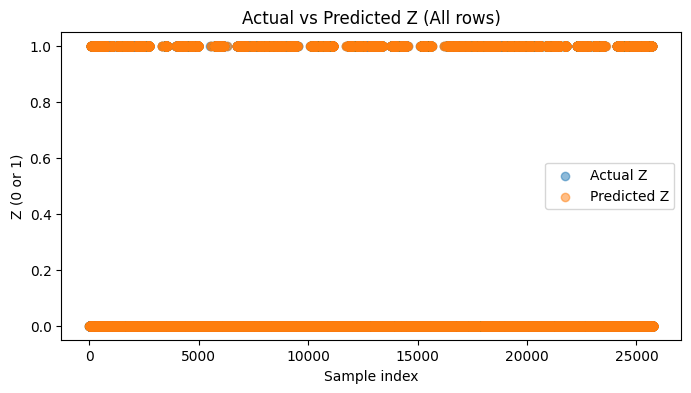

In [11]:
plt.figure(figsize=(8,4))
plt.scatter(range(len(y)), y, label='Actual Z', alpha=0.5)
plt.scatter(range(len(y_pred)), y_pred, label='Predicted Z', alpha=0.5)
plt.title("Actual vs Predicted Z (All rows)")
plt.xlabel("Sample index")
plt.ylabel("Z (0 or 1)")
plt.legend()
plt.show()


histogram of predicted probabilities

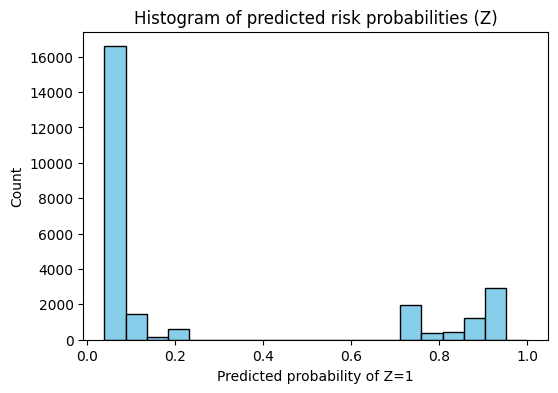

In [8]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
plt.hist(y_pred_prob, bins=20, color='skyblue', edgecolor='black')
plt.title("Histogram of predicted risk probabilities (Z)")
plt.xlabel("Predicted probability of Z=1")
plt.ylabel("Count")
plt.show()


logistic coefficients

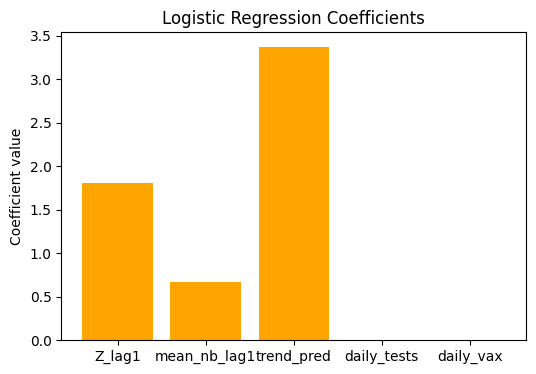

In [9]:
plt.figure(figsize=(6,4))
plt.bar(feat_cols, clf.coef_[0], color='orange')
plt.title("Logistic Regression Coefficients")
plt.ylabel("Coefficient value")
plt.show()


State-wise predicted probability over time

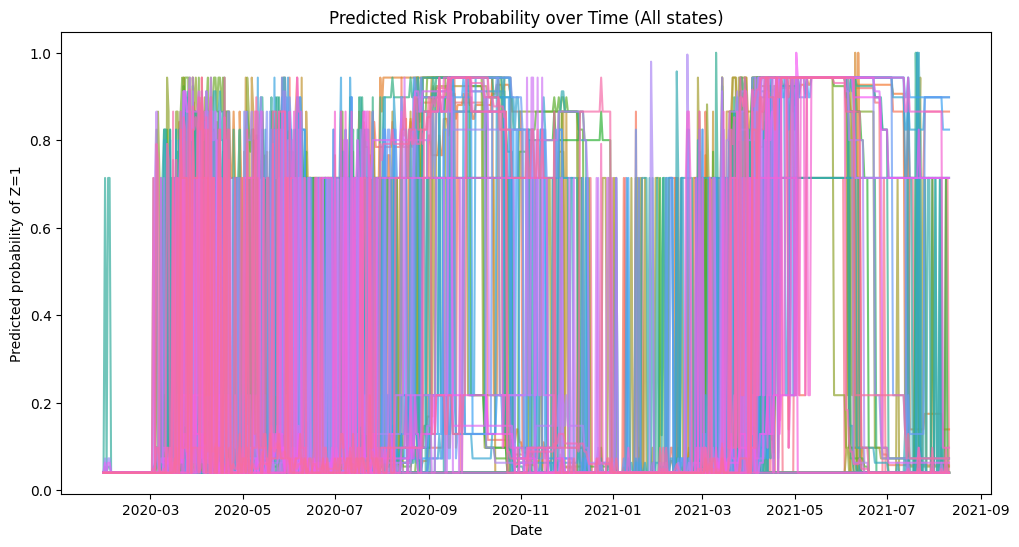

In [13]:
import seaborn as sns

train['Z_pred_prob'] = y_pred_prob
plt.figure(figsize=(12,6))
sns.lineplot(data=train, x='Date', y='Z_pred_prob', hue='state', legend=False, alpha=0.7)
plt.title("Predicted Risk Probability over Time (All states)")
plt.ylabel("Predicted probability of Z=1")
plt.xlabel("Date")
plt.show()


Heatmap of predicted probabilities (states vs dates)

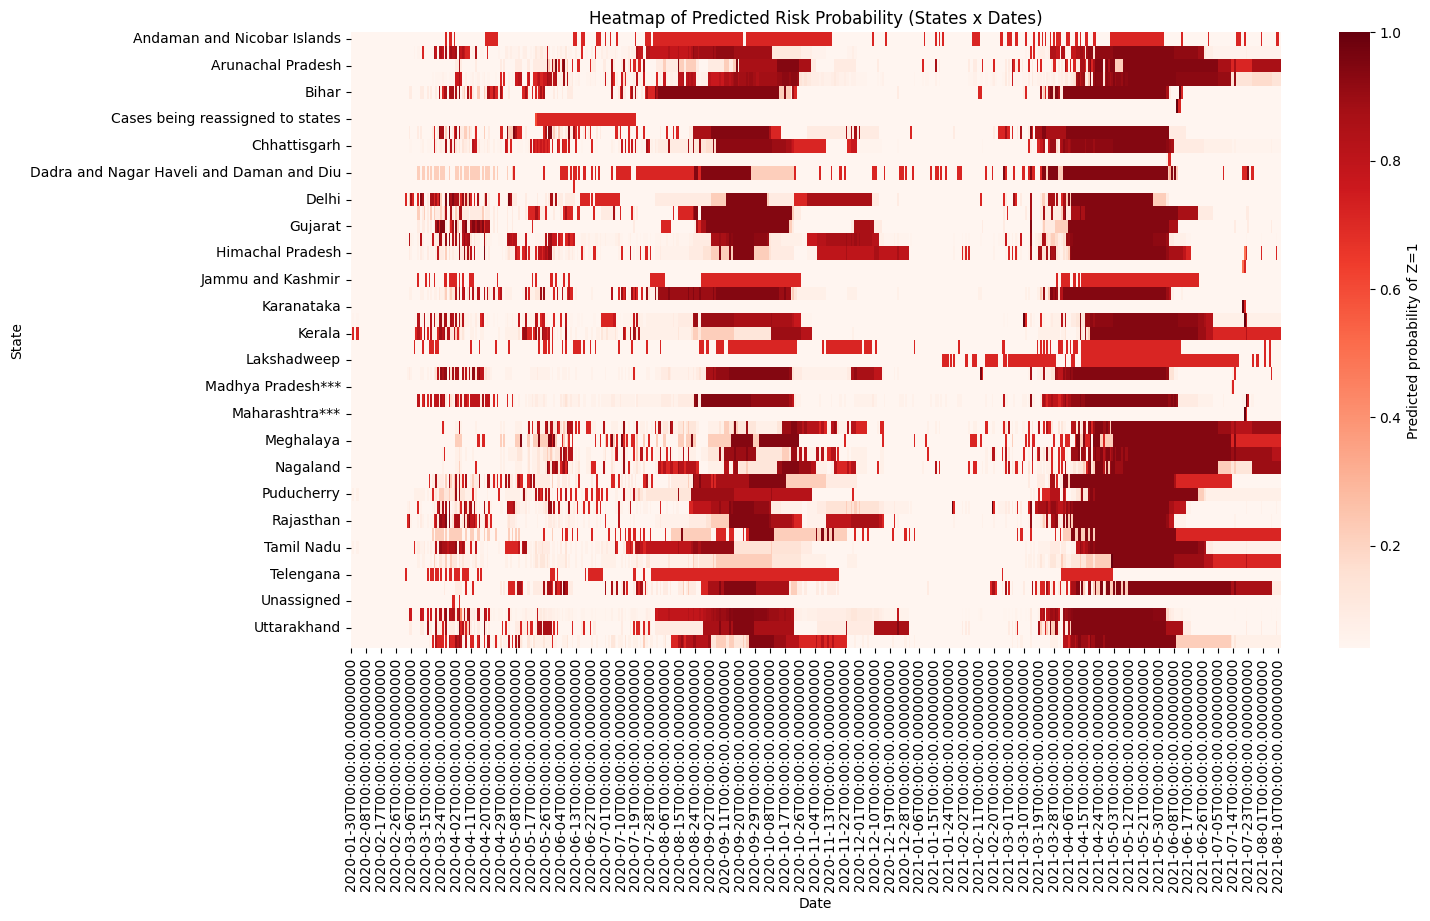

In [15]:
pivot = train.pivot_table(
    index='state',
    columns='Date',
    values='Z_pred_prob',
    aggfunc='mean'  # or 'max', 'min', etc.
)

plt.figure(figsize=(15,8))
sns.heatmap(pivot, cmap='Reds', cbar_kws={'label':'Predicted probability of Z=1'})
plt.title("Heatmap of Predicted Risk Probability (States x Dates)")
plt.xlabel("Date")
plt.ylabel("State")
plt.show()


In [18]:
# after clf.fit(...)
y_pred_prob = clf.predict_proba(Xs)[:,1]  # probability of Z=1

df_out = pd.DataFrame({
    "date_for": train["Date"].values,
    "state": train["state"].values,
    "prob": y_pred_prob,
    "true_label": y
})

# save for evaluate.py
out_path = r"C:\Users\dedee\Downloads\epidemic-project\results\predictions_with_truth.csv"
import os
os.makedirs(os.path.dirname(out_path), exist_ok=True)
df_out.to_csv(out_path, index=False)
print("Saved predictions to:", out_path)


Saved predictions to: C:\Users\dedee\Downloads\epidemic-project\results\predictions_with_truth.csv
